# IMT 574 Final Project Report<br>Airbnb Rating Prediction and Feature Importance in Seattle
### Team members: Jimin Keel, Vivien Wang, Anna Chi

## 1. Describe The Dataset You Chose: Seattle Airbnb Dataset (8pts)

### a. Why did you choose it?

We use the ```Seattle Airbnb dataset``` from ```Inside Airbnb```. The dataset is publicly available and provides rich information on listings, hosts, geographic attributes, listing characteristics, and review scores. This allows us to analyze factors that influence Airbnb ratings and identify what drives user satisfaction.

### b. What features does it include?

The dataset includes information on listings, hosts, geographic attributes, listing characteristics, and review scores. It contains numeric features (e.g., price, number of bedrooms), categorical features (e.g., room type, property type), and unstructured data such as text descriptions and images related to listings and hosts.

### c. What year is it from?

The data is based on a snapshot of Airbnb listings scraped in September 2025.

### d. How was it collected?

The dataset was obtained from the Inside Airbnb open dataset, which collects publicly available Airbnb listing data through web scraping (https://insideairbnb.com/get-the-data/).

### e. What should we know about this dataset as we read your writeup?

- For the target variable, the original 1–5 rating scale had limited variance and was not suitable for regression. Therefore, we converted it into a binary class (high 50% vs. low 50%) for classification.

- This dataset contains 79 columns, including valuable unstructured data such as text and images. In this study, we focus only on numeric and categorical features, selected based on considerations such as multicollinearity. For example, “host_is_superhost” is a strong predictor but was excluded because the superhost badge is directly associated with high ratings.

## 2. Define a research question. (4pts)

### a. What are you trying to predict?

We aim to predict ```Airbnb listing rating score classes (high vs. low)``` based on ```listing, host, and the number of reviews features```.

### b. Describe what you're trying to accomplish.

We are trying to answer the following research questions:

#### [Main Question] Which features are most important in predicting Airbnb listing rating scores class?
To answer this, we apply supervised learning models, including Gradient Boosting, Random Forest, and K-Nearest Neighbors (KNN), and examine feature importance from tree-based models to identify key predictors.

#### [Sub Question] Does the importance of these features differ across neighborhoods compared to overall Seattle?
To address this, we compare feature importance across six neighborhoods in Seattle using Gradient Boosting models (the model with the best accuracy) to identify location-specific differences.

## 3. Why is this algorithm a good way of answering your research question? (4pts)

We selected ```Gradient Boosting```, ```Random Forest```, and ```K-Nearest Neighbors (KNN)``` based on their suitability for our prediction task.

Tree-based models such as ```Gradient Boosting``` and ```Random Forest``` work well for nonlinear binary classification and can capture interactions between features. They also provide feature importance, which helps us identify the most important predictors of Airbnb ratings.

We included ```KNN``` as a comparison model. Although it does not provide feature importance, it allows us to compare prediction performance with a different type of model.

After comparing performance, we selected ```Gradient Boosting``` as our main model because it achieved the highest accuracy. </br>

## 4. Read Data & Run the Models (10pts)
### : Using the data you chose and the algorithm you chose, read in your data and run your model.

#### **Main Question: Which features are most important in predicting Airbnb listing rating scores?**

### 4-1. Data Processing

In [32]:
# Import Packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
from sklearn.metrics import ConfusionMatrixDisplay
import shap

pd.set_option('display.max_columns', None)

In [33]:
# Load the Dataset
raw = pd.read_csv("listings.csv.gz")

# Check the Dataset
raw.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,6606,https://www.airbnb.com/rooms/6606,20250925032813,2025-09-25,city scrape,"Fab, private seattle urban cottage!","This tiny cottage is only 15x10, but it has ev...","A peaceful yet highly accessible neighborhood,...",https://a0.muscache.com/pictures/45742/21116d7...,14942,https://www.airbnb.com/users/show/14942,Joyce,2009-04-26,"Seattle, WA",I am a therapist/innkeeper.I know my city well...,within a few hours,100%,82%,t,https://a0.muscache.com/im/users/14942/profile...,https://a0.muscache.com/im/users/14942/profile...,Wallingford,5.0,5.0,"['email', 'phone']",t,t,Neighborhood highlights,Wallingford,Other neighborhoods,47.65444,-122.33629,Entire guesthouse,Entire home/apt,1,1.0,1 bath,1.0,1.0,"[""Free parking on premises"", ""Dedicated worksp...",$99.00,30,1125,30.0,30.0,1125.0,1125.0,30.0,1125.0,NaN,t,27,57,87,177,2025-09-25,161,0,0,95,1,0,0.0,2009-07-17,2024-09-07,4.60,4.67,4.67,4.83,4.77,4.88,4.57,str-opli-19-002622,f,3,3,0,0,0.82
1,9419,https://www.airbnb.com/rooms/9419,20250925032813,2025-09-25,city scrape,Glorious sun room w/ memory foambed,This beautiful double room features sun filled...,"Lots of restaurants (see our guide book) bars,...",https://a0.muscache.com/pictures/56645186/e5fb...,30559,https://www.airbnb.com/users/show/30559,Angielena,2009-08-09,"Seattle, WA",I am a visual artist who is the director ...,within an hour,100%,97%,t,https://a0.muscache.com/im/pictures/user/User-...,https://a0.muscache.com/im/pictures/user/User-...,Georgetown,10.0,11.0,"['email', 'phone']",t,t,Neighborhood highlights,Georgetown,Other neighborhoods,47.55017,-122.31937,Private room in rental unit,Private room,2,3.0,3 shared baths,1.0,2.0,"[""Baking sheet"", ""Luggage dropoff allowed"", ""C...",$71.00,2,90,2.0,2.0,90.0,90.0,2.0,90.0,NaN,t,0,22,52,327,2025-09-25,220,14,1,60,14,84,5964.0,2010-07-30,2025-08-31,4.73,4.80,4.75,4.92,4.89,4.70,4.69,Exempt,f,10,0,10,0,1.19
2,9596,https://www.airbnb.com/rooms/9596,20250925032813,2025-09-25,previous scrape,"the down home , spacious, central and fab!","We are in a great neighborhood, quiet, full of...","if you arrive early for check in at 3, I reco...",https://a0.muscache.com/pictures/665252/102d18...,14942,https://www.airbnb.com/users/show/14942,Joyce,2009-04-26,"Seattle, WA",I am a therapist/innkeeper.I know my city well...,within a few hours,100%,82%,t,https://a0.muscache.com/im/users/14942/profile...,https://a0.muscache.com/im/users/14942/profile...,Wallingford,5.0,5.0,"['email', 'phone']",t,t,Neighborhood highlights,Wallingford,Other neighborhoods,47.65608,-122.33602,Entire rental unit,Entire home/apt,4,

##### Interesting Columns (Target Variable / Feature Candidates)
  
- **Target variable**: `review_scores_rating` (we convert the original 1–5 scale into two classes to address the limited variance in ratings.)
- **Index**: `neighbourhood_group_cleansed` (used to analyze differences in feature importance by neighborhood)
- **Feature candidates and hypothesis**
  1. `relative price`: A more competitive price compared to similar listings may increase scores (we create a relative price feature).
  2. `room_type`: Private rooms may be associated with higher scores.
  3. `bedrooms`: More bedrooms may be associated with higher scores.
  4. `bathrooms`: More bathrooms may be associated with higher scores.
  5. `beds`: More beds may be associated with higher scores.
  6. `accommodates`: Listings that accommodate more guests may be associated with higher scores.
  7. `minimum_nights`: Shorter minimum stays may be associated with higher scores (we will create an is_long_term feature).
  8. `host_response_time`: Faster response times may be associated with higher scores.
  9. `host_identity_verified`: Verified hosts may be perceived as more reliable, leading to higher scores.
  10. `number_of_reviews`: Listings with more reviews may be associated with higher scores.
  11. `number_of_reviews_ltm`: A higher proportion of recent reviews may be associated with higher scores (we will create recent_review_proportion = reviews_ltm / total reviews).
  12. `estimated_occupancy_l365d`: Lower occupancy may be associated with higher scores.

In [34]:
# Choose Only Interesting Columns and Create a New Dataset
cols_interested = ["price", "neighbourhood_group_cleansed", "room_type", "bedrooms", "bathrooms",
                   "beds", "accommodates", "minimum_nights", "host_response_time",
                   "host_identity_verified", "number_of_reviews", "number_of_reviews_ltm",
                   "estimated_occupancy_l365d", "review_scores_rating"
                  ]

raw_clean = raw[cols_interested].copy()

# Check the Dataset
raw_clean.describe()

,bedrooms,bathrooms,beds,accommodates,minimum_nights,number_of_reviews,number_of_reviews_ltm,estimated_occupancy_l365d,review_scores_rating
count,6845.000000,6288.000000,6285.000000,6996.000000,6996.000000,6996.000000,6996.000000,6996.000000,6109.000000
mean,1.661066,1.456266,2.157677,4.010292,10.990709,82.307604,16.992138,105.077330,4.808836
std,1.182109,0.834621,1.519486,2.595572,18.718235,126.641425,21.979380,93.147852,0.338030
min,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,1.000000,2.000000,1.000000,5.000000,1.000000,6.000000,4.780000
50%,1.000000,1.000000,2.000000,4.000000,2.000000,32.000000,9.000000,86.000000,4.900000
75%,2.000000,2.000000,3.000000,5.000000,30.000000,105.000000,27.000000,182.000000,4.980000
max,13.000000,16.000000,15.000000,16.000000,365.000000,1577.000000,562.000000,255.000000,5.000000


In [35]:
raw_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6996 entries, 0 to 6995
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   price                         6221 non-null   object 
 1   neighbourhood_group_cleansed  6996 non-null   object 
 2   room_type                     6996 non-null   object 
 3   bedrooms                      6845 non-null   float64
 4   bathrooms                     6288 non-null   float64
 5   beds                          6285 non-null   float64
 6   accommodates                  6996 non-null   int64  
 7   minimum_nights                6996 non-null   int64  
 8   host_response_time            5927 non-null   object 
 9   host_identity_verified        6645 non-null   object 
 10  number_of_reviews             6996 non-null   int64  
 11  number_of_reviews_ltm         6996 non-null   int64  
 12  estimated_occupancy_l365d     6996 non-null   int64  
 13  rev

### 4-2. Feature Engineering

In [36]:
# Convert Data Type
raw_clean["price"] = (raw_clean["price"].replace(r"[\$,]", "", regex=True).astype(float))
raw_clean["price"].describe()

count     6221.000000
mean       571.716123
std       4137.408761
min         15.000000
25%        105.000000
50%        149.000000
75%        212.000000
max      50039.000000
Name: price, dtype: float64

In [37]:
# Filter Extreme "price", "bedrooms", "beds", "bathrooms", "accommodates" (data <= 99%)
cols_to_filter = ["price", "bedrooms", "beds", "bathrooms", "accommodates"]
p99 = raw_clean[cols_to_filter].quantile(0.99)

for col in cols_to_filter:
    raw_clean = raw_clean[raw_clean[col] <= p99[col]]

raw_clean.describe()  # Data Count: 6221 -> 6060

,price,bedrooms,bathrooms,beds,accommodates,minimum_nights,number_of_reviews,number_of_reviews_ltm,estimated_occupancy_l365d,review_scores_rating
count,6060.000000,6060.000000,6060.000000,6060.000000,6060.000000,6060.000000,6060.000000,6060.000000,6060.000000,5355.000000
mean,173.090594,1.594224,1.417327,2.090099,3.908581,10.652310,87.301815,18.351485,112.433333,4.809899
std,121.788743,1.077091,0.677130,1.308169,2.312711,18.039093,130.440000,22.416533,92.736674,0.328127
min,15.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,104.000000,1.000000,1.000000,1.000000,2.000000,1.000000,6.000000,1.000000,18.000000,4.780000
50%,146.000000,1.000000,1.000000,2.000000,4.000000,2.000000,36.000000,12.000000,102.000000,4.900000
75%,206.000000,2.000000,2.000000,3.000000,5.000000,30.000000,113.000000,29.000000,198.000000,4.980000
max,1717.000000,6.000000,4.000000,8.000000,14.000000,365.000000,1577.000000,562.000000,255.000000,5.000000


In [38]:
# Convert "host_response_time" from str to ordinal value
mapping = {
    "within an hour": 1,
    "within a few hours": 2,
    "within a day": 3,
    "a few days or more": 4
}

raw_clean["host_response_time"] = raw_clean["host_response_time"].map(mapping)

# Create "is_long_term" Column (long-term listing if "minimun nights" > 7)
raw_clean["is_long_term"] = (raw_clean["minimum_nights"] > 7).astype(int)

# Create "recent_review_proportion" Column ("number_of_reviews_ltm" / "number_of_reviews")
raw_clean["recent_review_proportion"] = raw_clean["number_of_reviews_ltm"] / raw_clean["number_of_reviews"]

# Create "relative_price" Column
condition = ["bedrooms", "bathrooms", "neighbourhood_group_cleansed", "room_type"]
raw_clean["avg_price_group"] = raw_clean.groupby(condition)["price"].transform("mean")
raw_clean["relative_price"] = raw_clean["price"] / raw_clean["avg_price_group"]

# Create the Final Dataset
cols_cleaned = [
    # target variable candidate (we will convert this to review_scores_class before training model.)
    "review_scores_rating",
    # index
    "neighbourhood_group_cleansed",
    # features - pricing
    "relative_price",
    # features - house attributes
    "room_type",
    "bedrooms",
    "beds",
    "bathrooms",
    "accommodates",
    "is_long_term",
    # features - host attributes
    "host_response_time",
    "host_identity_verified", 
    # features - others
    "number_of_reviews",
    "recent_review_proportion",
    "estimated_occupancy_l365d"
]

# Drop Null Values
df = raw_clean[cols_cleaned].dropna()

#Check the Final Data
df.describe() # Data Count: 6060 -> 4863

,review_scores_rating,relative_price,bedrooms,beds,bathrooms,accommodates,is_long_term,host_response_time,number_of_reviews,recent_review_proportion,estimated_occupancy_l365d
count,4863.000000,4863.000000,4863.000000,4863.000000,4863.000000,4863.000000,4863.000000,4863.000000,4863.000000,4863.000000,4863.000000
mean,4.813403,0.977189,1.641579,2.180341,1.442628,4.084104,0.195147,1.166153,102.333128,0.416107,131.525190
std,0.323130,0.353756,1.082590,1.326938,0.685543,2.361011,0.396355,0.511036,137.474692,0.360844,87.387552
min,1.000000,0.119912,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,4.790000,0.768085,1.000000,1.000000,1.000000,2.000000,0.000000,1.000000,15.000000,0.115413,60.000000
50%,4.900000,0.925709,1.000000,2.000000,1.000000,4.000000,0.000000,1.000000,50.000000,0.285714,120.000000
75%,4.980000,1.108341,2.000000,3.000000,2.000000,6.000000,0.000000,1.000000,132.000000,0.728043,216.000000
max,5.000000,6.959716,6.000000,8.000000,4.000000,14.000000,1.000000,4.000000,1577.000000,1.000000,255.000000


In [39]:
# Converting df to csv
df.to_csv("seattle_filtered.csv", index=False)

### 4-3. Run the Models & Model Evaluation

For this section, we use ```Gradient Boosting Classifier```, ```Random Forest Classifier```, ```KNN``` to test the accuracy of prediction. <br>

#### 3-1. Train, Test Split

In [40]:
X = df.drop(columns=["review_scores_rating", "neighbourhood_group_cleansed"])
y = (df["review_scores_rating"] >=
     df["review_scores_rating"].quantile(0.50)).astype(int) # rating class threshold : 4.90)

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### 3-2. [Model 1] Gradient Boosting Classifier

In [41]:
# Hyperparameter optimization: finding the best learning rate (lr), number of trees (n), tree depth (depth), and subsample rate (ss).
best_score = 0
best_params = None

for lr in [0.01, 0.05, 0.1]:
    for n in [500, 600, 700, 800]:
        for depth in [2, 3, 4]:
            for ss in [0.8, 1.0]:
                gb = GradientBoostingClassifier(learning_rate=lr,
                                                n_estimators=n,
                                                max_depth=depth,
                                                subsample=ss,
                                                random_state=42)
                gb.fit(X_train, y_train)
                acc = accuracy_score(y_test, gb.predict(X_test))
                print(f"lr={lr}, n={n}, depth={depth}, subsample={ss}: {acc:.4f}")
                
                if acc > best_score:
                    best_score = acc
                    best_params = (lr, n, depth, ss)

print(f"\nBest: lr={best_params[0]}, n={best_params[1]}, depth={best_params[2]}, subsample={best_params[3]} ({best_score:.4f})")

lr=0.01, n=500, depth=2, subsample=0.8: 0.6372
lr=0.01, n=500, depth=2, subsample=1.0: 0.6280
lr=0.01, n=500, depth=3, subsample=0.8: 0.6454
lr=0.01, n=500, depth=3, subsample=1.0: 0.6495
lr=0.01, n=500, depth=4, subsample=0.8: 0.6547
lr=0.01, n=500, depth=4, subsample=1.0: 0.6598
lr=0.01, n=600, depth=2, subsample=0.8: 0.6393
lr=0.01, n=600, depth=2, subsample=1.0: 0.6341
lr=0.01, n=600, depth=3, subsample=0.8: 0.6495
lr=0.01, n=600, depth=3, subsample=1.0: 0.6608
lr=0.01, n=600, depth=4, subsample=0.8: 0.6567
lr=0.01, n=600, depth=4, subsample=1.0: 0.6608
lr=0.01, n=700, depth=2, subsample=0.8: 0.6454
lr=0.01, n=700, depth=2, subsample=1.0: 0.6403
lr=0.01, n=700, depth=3, subsample=0.8: 0.6495
lr=0.01, n=700, depth=3, subsample=1.0: 0.6629
lr=0.01, n=700, depth=4, subsample=0.8: 0.6588
lr=0.01, n=700, depth=4, subsample=1.0: 0.6608
lr=0.01, n=800, depth=2, subsample=0.8: 0.6454
lr=0.01, n=800, depth=2, subsample=1.0: 0.6413
lr=0.01, n=800, depth=3, subsample=0.8: 0.6506
lr=0.01, n=80

In [42]:
# Run Gradient Boosting Classifier
gb = GradientBoostingClassifier(learning_rate=0.01,
                                n_estimators=800,
                                max_depth=3,
                                subsample=1.0,
                                random_state=42)

gb.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.01
,n_estimators,800
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [43]:
# Check Test Accuracy: 0.6650, Higher than baseline (0.5000)
y_pred = gb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6649537512846866
[[284 192]
 [134 363]]
              precision    recall  f1-score   support

           0       0.68      0.60      0.64       476
           1       0.65      0.73      0.69       497

    accuracy                           0.66       973
   macro avg       0.67      0.66      0.66       973
weighted avg       0.67      0.66      0.66       973



#### 3-3. [Model 2] Random Forest Classifier

In [44]:
# Hyperparameter optimization: finding the best number of trees (n) and tree depth (depth).
best_score = 0
best_params = None

for n in [30, 40, 50, 75, 100, 200, 300]:
    for depth in [5, 10, 20, 30]:
        rf = RandomForestClassifier(n_estimators=n,
                                    max_depth=depth,
                                    random_state=42)
        rf.fit(X_train, y_train)
        acc = accuracy_score(y_test, rf.predict(X_test))
        print(f"n={n}, depth={depth}: {acc:.4f}")

        if acc > best_score:
            best_score = acc
            best_params = (n, depth)

print(f"\nBest: n={best_params[0]}, depth={best_params[1]} ({best_score:.4f})")

n=30, depth=5: 0.6403
n=30, depth=10: 0.6495
n=30, depth=20: 0.6146
n=30, depth=30: 0.6249
n=40, depth=5: 0.6331
n=40, depth=10: 0.6526
n=40, depth=20: 0.6321
n=40, depth=30: 0.6290
n=50, depth=5: 0.6310
n=50, depth=10: 0.6465
n=50, depth=20: 0.6331
n=50, depth=30: 0.6259
n=75, depth=5: 0.6310
n=75, depth=10: 0.6485
n=75, depth=20: 0.6434
n=75, depth=30: 0.6290
n=100, depth=5: 0.6331
n=100, depth=10: 0.6495
n=100, depth=20: 0.6382
n=100, depth=30: 0.6290
n=200, depth=5: 0.6393
n=200, depth=10: 0.6516
n=200, depth=20: 0.6362
n=200, depth=30: 0.6372
n=300, depth=5: 0.6413
n=300, depth=10: 0.6506
n=300, depth=20: 0.6403
n=300, depth=30: 0.6321

Best: n=40, depth=10 (0.6526)


In [45]:
# Run Random Forest Classifier
rf = RandomForestClassifier(n_estimators=40,
                            max_depth=10,
                            random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,40
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [46]:
# Check Test Accuracy: 0.6526, Higher than baseline (0.5000)
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6526207605344296
[[281 195]
 [143 354]]
              precision    recall  f1-score   support

           0       0.66      0.59      0.62       476
           1       0.64      0.71      0.68       497

    accuracy                           0.65       973
   macro avg       0.65      0.65      0.65       973
weighted avg       0.65      0.65      0.65       973



#### 3-4. [Model 3] K-Nearest Neighbors

In [47]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
# Hyperparameter optimization: the number of K
best_score = 0
best_params = None

for k in range(3, 30, 2):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test_scaled))
    print(f"k={k}: {acc:.4f}")

    if acc > best_score:
        best_score = acc
        best_params = k

print(f"\nBest: k={best_params} ({best_score:.4f})")

k=3: 0.5982
k=5: 0.5971
k=7: 0.5961
k=9: 0.6033
k=11: 0.6033
k=13: 0.6095
k=15: 0.6218
k=17: 0.6187
k=19: 0.6197
k=21: 0.6177
k=23: 0.6074
k=25: 0.6074
k=27: 0.6166
k=29: 0.6177

Best: k=15 (0.6218)


In [49]:
# Run KNN
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train_scaled, y_train)

,n_neighbors,15
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [51]:
# Check Test Accuracy: 0.6218, Higher than baseline (0.5000)
y_pred = knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6217882836587872
[[266 210]
 [158 339]]
              precision    recall  f1-score   support

           0       0.63      0.56      0.59       476
           1       0.62      0.68      0.65       497

    accuracy                           0.62       973
   macro avg       0.62      0.62      0.62       973
weighted avg       0.62      0.62      0.62       973



## 5. Hyperparameter Sensitivity Analysis (6pts)
### : Conduct a hyperparameter sensitivity analysis by systematically varying key model parameters and measuring their impact on model performance. You only need to do this for one hyperparameter if your selected algorithm has multiple.

We conducted hyperparameter tuning for all three models by systematically varying key parameters and measuring their impact on accuracy.

1. ```Gradient Boosting```

- Tuned parameters: learning rate, number of estimators, tree depth, subsample ratio
- Best parameters: learning rate = 0.01, n_estimators = 800, depth = 3, subsample = 1.0
- **Accuracy improved from 0.6249 → 0.6650 (+0.0401)**
- Lower learning rates with more estimators led to more stable and higher performance.

2. ```Random Forest```

- Tuned parameters: number of estimators, tree depth
- Best parameters: n_estimators = 40, depth = 10
- **Accuracy improved from 0.6146 → 0.6526 (+0.0380)**
- Moderate depth performed better than very shallow or very deep trees.

3. ```K-Nearest Neighbors (KNN)```

- Tuned parameter: number of neighbors (k)
- Best parameter: k = 15
- **Accuracy improved from 0.5961 → 0.6218 (+0.0257)**
- Increasing k improved performance up to a stable point.

Overall, all models showed improved performance after tuning, with ```Gradient Boosting``` achieving the largest improvement.

## 6. Model Evaluation (6pts)
### : Report the evaluation of your model. Either through RMSE, F1 score, or another metric. How did accuracy/evaluation change with hyperparameter selection?

Since our target variable was converted into a balanced binary classification (50% high vs. 50% low), we used ```accuracy``` as the primary evaluation metric.

After training each model with its optimal hyperparameters, we compared their performance:

```Gradient Boosting```: accuracy = 0.6650

```Random Forest```: accuracy = 0.6526

```KNN```: accuracy = 0.6218

All models outperformed the baseline accuracy of 0.5000, indicating that they successfully captured meaningful patterns in the data.

Hyperparameter tuning led to noticeable improvements in accuracy for all models, with ```Gradient Boosting``` showing the highest gain and best overall performance.

**Based on this comparison, we selected ```Gradient Boosting``` as our main algorithm, as it achieved the highest accuracy (0.6650) and provides interpretable feature importance aligned with our research objectives.**

## 7. Visualization & Interpretation (8pts)
### : Create a visualization demonstrating your findings. Make sure to include a title and axis labels. Describe what’s being shown in your visualization.

### 7-1. Model Performance (Confusion Metrix)

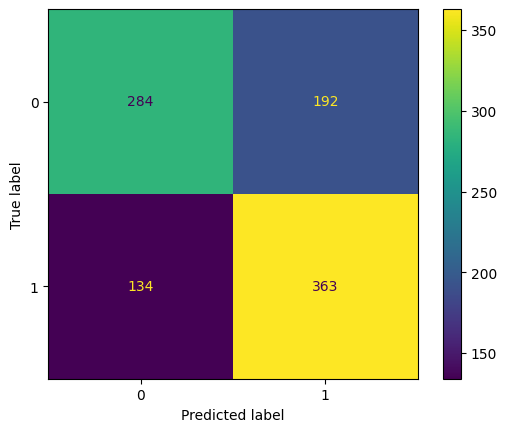

In [55]:
# Confusion Metrix Visualization
ConfusionMatrixDisplay.from_estimator(gb, X_test, y_test)

The model achieved an accuracy of 0.665, outperforming the baseline (0.50).

It performs better on high-rated listings (class 1) with higher recall (0.73) compared to low-rated listings (class 0) (0.60). Precision is relatively balanced across both classes.

Overall, the model tends to predict listings as high-rated, leading to more misclassification of low-rated listings.

### 7-2. Permutation Feature Importance

In [57]:
# Permutation Feature Importance Analysis
result = permutation_importance(gb, X_test, y_test, n_repeats=5, random_state=42)
perm_imp = pd.Series(result.importances_mean, index=X_test.columns)
perm_imp.sort_values(ascending=False).head(10)

relative_price               0.065159
recent_review_proportion     0.049332
number_of_reviews            0.030216
estimated_occupancy_l365d    0.029188
room_type_Private room       0.026310
bathrooms                    0.021583
bedrooms                     0.019527
host_response_time           0.013772
accommodates                 0.009661
is_long_term                 0.003494
dtype: float64

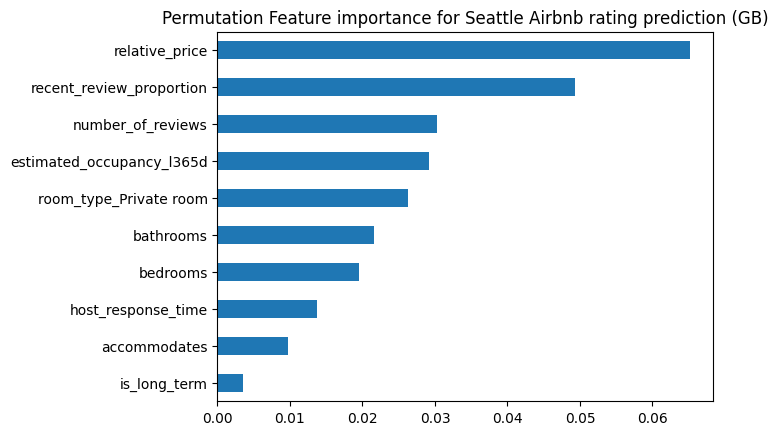

In [58]:
# Visualization
perm_imp.sort_values().tail(10).plot(kind="barh")
plt.title("Permutation Feature importance for Seattle Airbnb rating prediction (GB)")
plt.show()

`Relative price` is the most important feature, indicating that pricing compared to similar listings plays the largest role in predicting rating scores.

`Review-related variables`, such as recent review proportion and number of reviews, are also strong predictors, suggesting that user engagement and recent activity are closely associated with higher ratings.

`Occupancy and room characteristics` (e.g., `private room`, `bathrooms`, `bedrooms`) have moderate importance, while host-related features (e.g., response time) and minimum stay conditions have relatively smaller impact.

### 7-2. SHAP Analysis

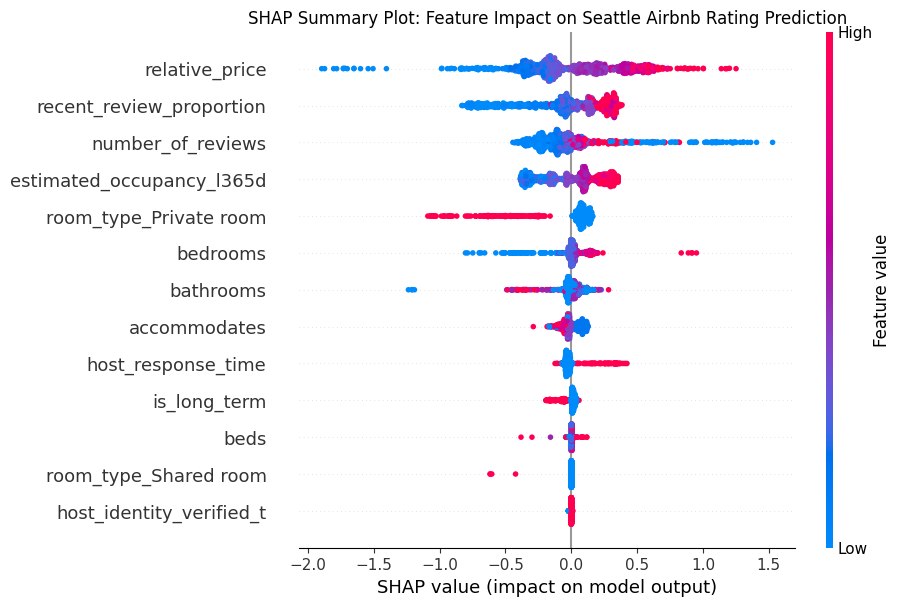

In [72]:
# Create SHAP Explainer
explainer = shap.Explainer(gb)

# Calcuate SHAP Values
shap_values = explainer(X_test)

# Beeswarm Plot
shap.plots.beeswarm(shap_values, max_display=len(X.columns), show=False)
plt.title("SHAP Summary Plot: Feature Impact on Seattle Airbnb Rating Prediction")
plt.show()

The SHAP summary plot shows that `relative price` and review-related features (`recent review proportion` and `number of reviews`) have the strongest influence on predicting Airbnb rating scores.

A higher value of `relative price` tends to increase the likelihood of a high rating. This suggests that listings with better overall quality tend to both charge higher prices and receive better reviews.

`The number of reviews` and `recent review proportion` also generally contribute positively, although their effects vary depending on other features.

In contrast, `private room listings` are associated with lower ratings, as indicated by their negative SHAP values. Among room types, private rooms—positioned between entire homes/apartments and shared rooms—appear to have a stronger negative impact on ratings compared to the other categories.

Other features, such as `bedrooms`, `bathrooms`, and `accommodates`, have relatively smaller and less consistent impacts on predictions.

#### **Sub Question: Does the importance of these features differ across neighborhoods compared to overall Seattle?**

We use `Gradient Boosting` as our algorithm to do the features importance across cities compared to overall Seattle. To decide the areas we want to research, we pick neighbourhoods with 100+ rows and more than 60%+ accuracy.

In [79]:
def run_gb_by_area(df, area_name, target_col="review_scores_rating", min_rows=100,
                   test_size=0.2, random_state=42, plot_top_n=10):
    df = df.dropna(subset=[target_col]).copy()

    if len(df) < min_rows:
        raise ValueError(f"{area_name}: Not enough rows ({len(df)})")

    # threshold
    thres = df[target_col].quantile(0.5)

    # X, y
    X = df.drop(columns=[target_col]).copy()
    y = (df[target_col] >= thres).astype(int)

    # one-hot encoding
    X = pd.get_dummies(X, drop_first=True)

    if y.nunique() < 2:
        raise ValueError(f"{area_name}: Only one class in target")

    # split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    gb = GradientBoostingClassifier(learning_rate=0.05,
                                    n_estimators=500,
                                    max_depth=4,
                                    subsample=1.0,
                                    random_state=42)
    gb.fit(X_train, y_train)
    
    # prediction
    y_pred = gb.predict(X_test)

    # permutation feature importance
    result = permutation_importance(gb, X_test, y_test, n_repeats=5, random_state=42)
    perm_imp = pd.Series(result.importances_mean, index=X_test.columns)
    top_features = perm_imp.sort_values(ascending=False).head(plot_top_n)

    # results
    result = {
        "area": area_name,
        "threshold": thres,
        "accuracy": accuracy_score(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred, output_dict=True),
        "feature_importance": perm_imp,
        "top_features": top_features,
        "model": gb,
        "X_test": X_test
    }

    return result

area_list = df["neighbourhood_group_cleansed"].unique()

all_results = {}

for area in area_list:
    try:
        tmp = df[df['neighbourhood_group_cleansed'] == area]
        result = run_gb_by_area(tmp, area)
        all_results[area] = result

        if result["accuracy"] >= 0.60:
            print(f"\n=== {area} ===")
            print("Threshold:", result["threshold"])
            print("Accuracy:", result["accuracy"])
            print("Confusion Matrix:\n", result["confusion_matrix"])

    except Exception as e:
        print(f"\n=== {area} ===")
        print("Error:", e)


=== Other neighborhoods ===
Threshold: 4.92
Accuracy: 0.6908212560386473
Confusion Matrix:
 [[69 33]
 [31 74]]

=== Magnolia ===
Error: Magnolia: Not enough rows (83)

=== Queen Anne ===
Threshold: 4.91
Accuracy: 0.6
Confusion Matrix:
 [[19 17]
 [15 29]]

=== Downtown ===
Threshold: 4.85
Accuracy: 0.6513761467889908
Confusion Matrix:
 [[35 18]
 [20 36]]

=== Central Area ===
Threshold: 4.91
Accuracy: 0.6067415730337079
Confusion Matrix:
 [[25 19]
 [16 29]]

=== University District ===
Threshold: 4.67
Accuracy: 0.7674418604651163
Confusion Matrix:
 [[18  3]
 [ 7 15]]

=== Delridge ===
Threshold: 4.91
Accuracy: 0.6060606060606061
Confusion Matrix:
 [[10  6]
 [ 7 10]]

=== Northgate ===
Threshold: 4.84
Accuracy: 0.6060606060606061
Confusion Matrix:
 [[ 8  8]
 [ 5 12]]

=== Seward Park ===
Error: Seward Park: Not enough rows (47)

=== Lake City ===
Error: Lake City: Not enough rows (86)

=== Interbay ===
Error: Interbay: Not enough rows (14)


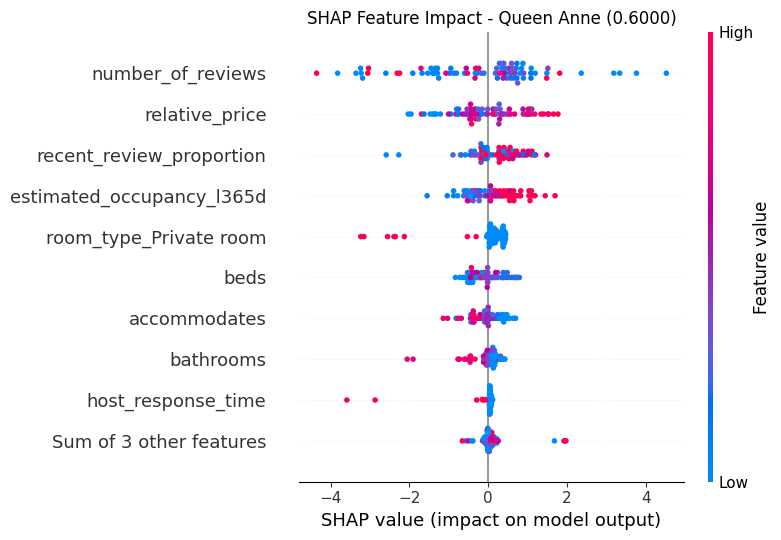

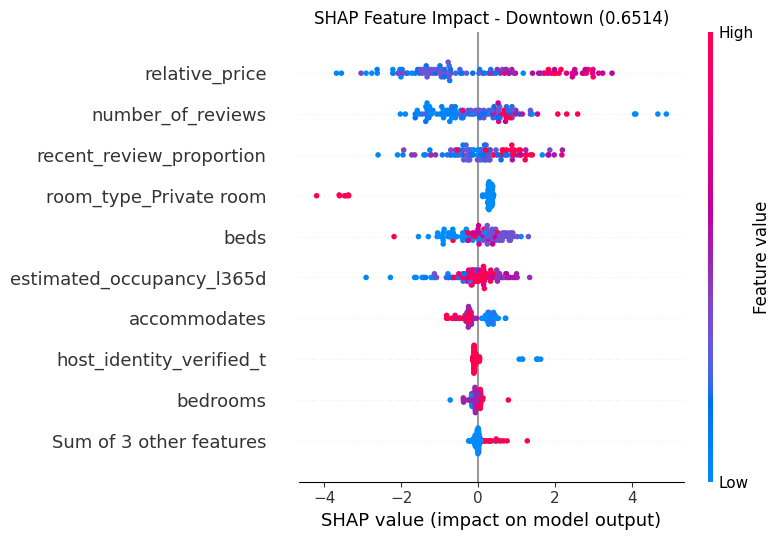

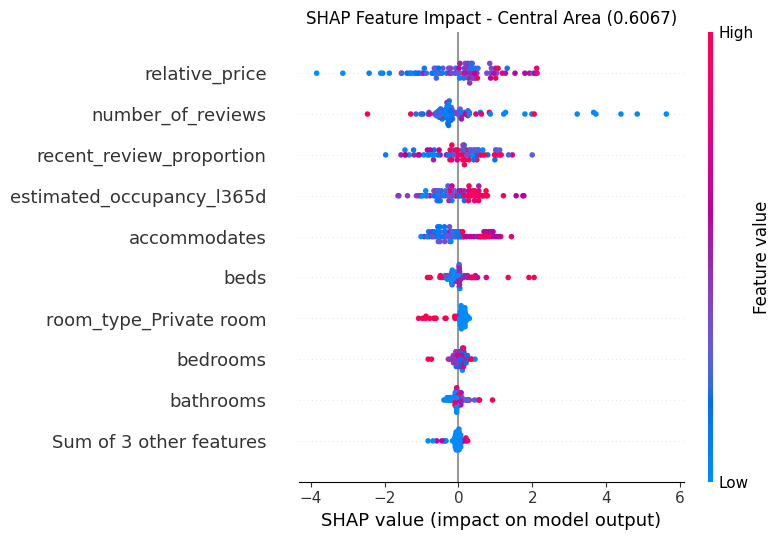

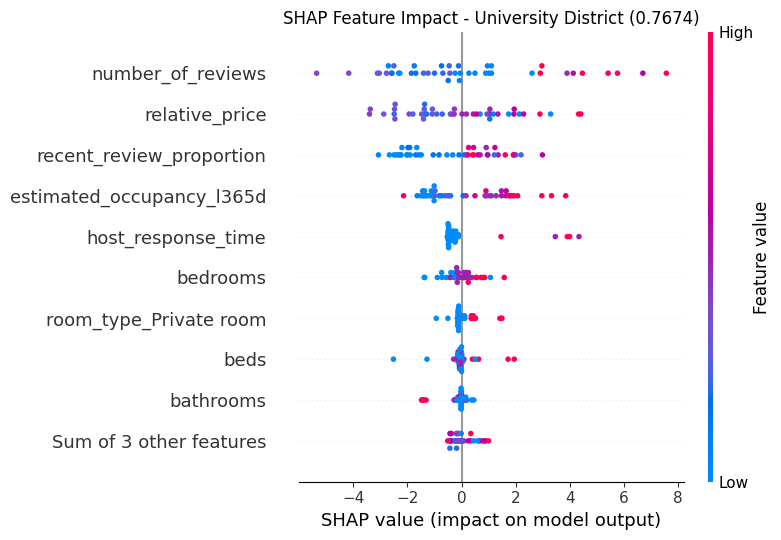

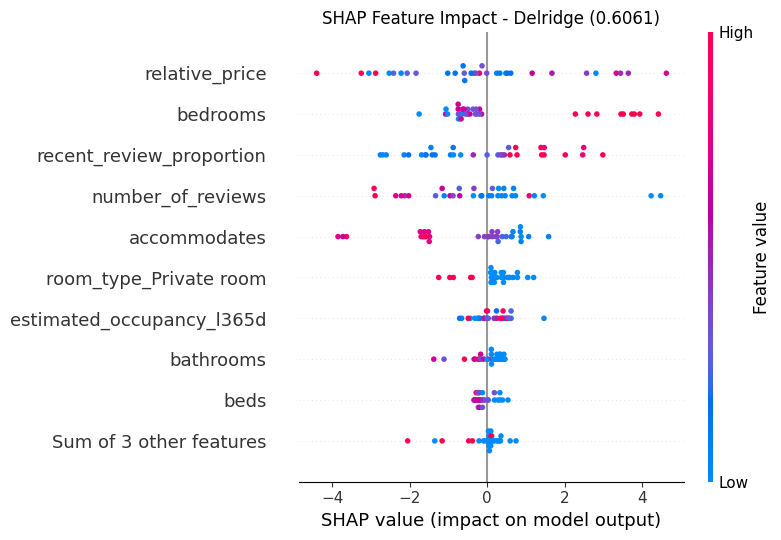

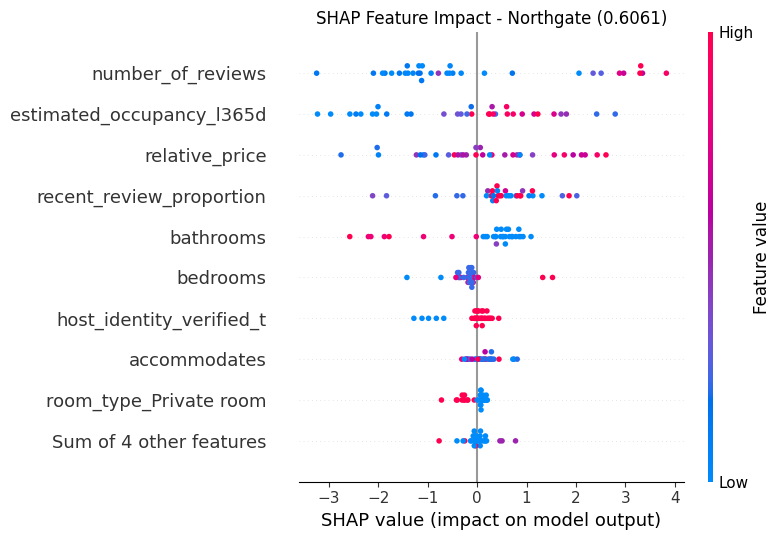

In [84]:
# SHAP Feature Impact Analysis
for area_name, result in all_results.items():
    if area_name == "Other neighborhoods":
        continue
    if result["accuracy"] < 0.60:
        continue

    model = result["model"]
    X_area = result["X_test"]

    explainer = shap.Explainer(model)
    shap_values = explainer(X_area)

    shap.plots.beeswarm(shap_values, max_display=10, show=False)
    plt.title(f"SHAP Feature Impact - {area_name} ({result['accuracy']:.4f})")
    plt.tight_layout()
    plt.show()

**Neighborhood Segmentation (SHAP-based, revised)**

**Group 1: Price-Sensitive** (`Downtown`, `Central Area`)

- Key: `relative_price`, `number_of_reviews`, `recent_review_proportion`
- Interpretation: Ratings are strongly driven by both price and review signals. Higher relative price consistently shows a positive effect, suggesting that price reflects underlying quality. Review-related features also contribute positively, reinforcing the role of social proof and recent activity in competitive, high-demand areas.

**Group 2: Review-Sensitive** (`U-District`)

- Key: `number_of_reviews`, `recent_review_proportion`
- Interpretation: Ratings are mainly influenced by review volume and recency, with relatively weaker price effects. Listings with more reviews and recent activity tend to receive higher ratings, indicating a fast-moving, feedback-driven market.

**Group 3: Occupancy-Sensitive** (`Northgate`, `Delridge`)

- Key: `estimated_occupancy_l365d`, `bedrooms`, `bathrooms`
- Interpretation: Ratings are associated with utilization and functional features. Higher occupancy generally has a positive effect, but overall patterns are more diffuse and less consistent, suggesting more heterogeneous demand and weaker market structure.

**Group 4: Price + Experience** (`Queen Anne`)

- Key: `relative_price`, `host_response_time`, `recent_review_proportion`
- Interpretation: Ratings depend on both price and host-related experience factors. Higher price and faster response time both contribute positively, indicating that service quality and responsiveness play an important role alongside pricing.

**Key Insight**
- While pricing and review signals are consistently important, their relative influence differs by neighborhood, reflecting distinct local market dynamics.

## 8. What challenges did you run into? (6pts)

### a. Do you think it was because of the data, the model, the research question?
One challenge we encountered early in the project was **defining a clear and feasible research question**. At first, we were interested in exploring Airbnb price differences between cities, states, or even countries. However, we quickly realized that the dataset lacked important variables needed for this type of analysis. For example, the dataset does not include booking date information, which makes it difficult to analyze seasonal pricing patterns.

Additionally, **comparing prices across different geographic areas introduces many complex factors** such as local demand, tourism, cost of living, and regional regulations. These differences made cross-location price analysis too complicated to conduct accurately with the available data.

Because of these limitations, we adjusted our research focus. Instead of predicting price, we decided to **predict Airbnb rating scores**. However, Airbnb ratings tend to have very little variation and are heavily skewed toward high values, which made regression models ineffective.

In addition, when comparing results across neighborhoods, we found that **model accuracy varied across areas**, making feature importance comparisons less straightforward. Some results were also counterintuitive, such as higher relative prices being associated with higher ratings, requiring additional interpretation beyond the model outputs.

### b. How would you overcome these challenges?

To address these issues, we reframed the task as a **classification** problem (high vs. low ratings), which improved model performance.

We also focused on **within-city analysis (Seattle)** instead of cross-region comparisons to reduce complexity. When comparing neighborhoods, we selected areas with sufficient data and reliable accuracy to ensure more meaningful comparisons.

Finally, we combined model outputs with **contextual interpretation** to better understand unexpected patterns and avoid misleading conclusions.

## 9. Explain how your machine learning solution answers the research question you defined. (10pts)

### a. Explain how your machine learning solution answers the research question you defined.
Our research question focuses on predicting Airbnb rating outcomes and identifying which features influence ratings across different neighborhoods in Seattle.

We use listing characteristics (e.g., price, room type, number of reviews, host features) as inputs to predict whether a listing receives a high or low rating.

Among the models tested, Gradient Boosting Classifier performed best. It captures nonlinear relationships and provides feature importance and SHAP values, allowing us to identify key drivers of ratings and compare them across neighborhoods.

### b. Describe the risks and advantages of applying your solution to unseen data. 

**Advantages:**
- Can uncover complex patterns not visible in simple analysis
- Helps hosts understand what factors improve ratings
- Helps users identify listings likely to have higher satisfaction

**Risks:**
- May overfit to current data and perform worse on new data
- Airbnb ratings are highly skewed, making subtle differences hard to predict
- Market conditions may change, reducing model reliability

### c. What are the consequences of your solution being wrong?
If incorrect, the model may
- Mislead hosts to focus on less important features
- Give users inaccurate expectations about listing quality
- Produce unreliable insights, especially across neighborhoods.

### d. What are advantages when it is right?
If accurate, the model may
- Provides actionable insights for hosts to improve listings
- Supports better decision-making for users
- Reveals how rating drivers differ by neighborhood

### e. What are some negative and positive societal impacts from your model?
**Positive impacts:**
- Improves transparency in what drives high ratings
- Encourages higher quality and consistency among hosts
- Makes booking decisions more efficient

**Negative impacts:**
- May reinforce inequalities (e.g., favoring higher-priced listings or certain areas)
- Could lead to over-reliance on quantitative signals, reducing attention to qualitative experience

## 10. Name one research question you might ask next for future work (don’t worry, you don’t have to do it!) Why is it important? (3pts)

One possible future research question is:<br>
**How do unstructured features (e.g., listing descriptions, review text, and images) affect the prediction of Airbnb rating scores?**

This question is important because the current model only uses structured features (numeric and categorical variables), while the dataset also contains rich unstructured data that likely captures aspects of user experience, sentiment, and visual appeal.

Incorporating text and image data could improve prediction performance and provide deeper insights into what drives user satisfaction beyond measurable listing attributes. This would make the model more realistic and better aligned with how users actually evaluate listings.

## 11. Create a Model Card (10pts)

![Model Card](modelcard.png)